## Support Vector Regressor

### Importing pipelines and libraries

In [2]:
import sys
sys.path.append(r"e:\SSPL_Internship_Repo\Sep_05_25\Tasks\Delivery_Time_Taken")
import warnings
warnings.filterwarnings("ignore", category=UserWarning)

In [3]:
from src.data_loader import load_data
from src.preprocessing import clean_data
from src.feature_engineering import add_features
from src.pipelines import get_pipeline
from src.evalute import print_scores

from sklearn.model_selection import train_test_split, RandomizedSearchCV, GridSearchCV
from sklearn.svm import SVR

### Loading train and test data sets

In [4]:
train_df = load_data(r"e:\SSPL_Internship_Repo\Sep_05_25\Tasks\Delivery_Time_Taken\data\train.csv")
test_df = load_data(r"e:\SSPL_Internship_Repo\Sep_05_25\Tasks\Delivery_Time_Taken\data\test.csv")

In [5]:
train_df = clean_data(train_df)
test_df = clean_data(test_df)

train_df = add_features(train_df)
test_df = add_features(test_df)

Column 'Time_taken(min)' not found in DataFrame!


### Defining Target feature and other features

In [6]:
target = "Time_taken(min)"

# Drop rows where target is missing
train_df = train_df.dropna(subset=[target])

numeric_features = [
    "Delivery_person_Age",
    "Delivery_person_Ratings",
    "multiple_deliveries",
    "distance_km",
    "order_to_pickup_time",
    "order_hour",
    "is_weekend"
]

categorical_features = [
    "Weatherconditions",
    "Road_traffic_density",
    "Type_of_order",
    "Type_of_vehicle",
    "Festival",
    "City"
]

X = train_df[numeric_features + categorical_features]
y = train_df[target]

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

### Fitting pipeline 

In [8]:
svr = SVR()

svr_pipeline = get_pipeline(svr, numeric_features, categorical_features)

### Hyperparameter tuning using grid search cv

In [9]:
param_grid = {
    "regressor__kernel": ["linear", "rbf"],
    "regressor__C": [0.1, 1, 10],
    "regressor__epsilon": [0.1, 0.2, 0.5]
}

grid = GridSearchCV(
    estimator=svr_pipeline,
    param_grid=param_grid,
    cv=3,
    scoring="r2",
    n_jobs=-1
)

In [10]:
grid.fit(X_train, y_train)

GridSearchCV(cv=3,
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(transformers=[('num',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer(strategy='median')),
                                                                                         ('scaler',
                                                                                          StandardScaler())]),
                                                                         ['Delivery_person_Age',
                                                                          'Delivery_person_Ratings',
                                                                          'multiple_deliveries',
                                                                          'distance_km',
                                                                          'order_to_pickup_time',
                                                                          'order_hour',
                                                                          'is_weekend']),
                                                                        ('cat',
                                                                         Pipeline(steps=[(...
                                                                                          SimpleImputer(strategy='most_frequent')),
                                                                                         ('encoder',
                                                                                          OneHotEncoder(handle_unknown='ignore'))]),
                                                                         ['Weatherconditions',
                                                                          'Road_traffic_density',
                                                                          'Type_of_order',
                                                                          'Type_of_vehicle',
                                                                          'Festival',
                                                                          'City'])])),
                                       ('regressor', SVR())]),
             n_jobs=-1,
             param_grid={'regressor__C': [0.1, 1, 10],
                         'regressor__epsilon': [0.1, 0.2, 0.5],
                         'regressor__kernel': ['linear', 'rbf']},
             scoring='r2')

In [11]:
print("Best Params:", grid.best_params_)
print("Best CV Score:", grid.best_score_)

Best Params: {'regressor__C': 10, 'regressor__epsilon': 0.5, 'regressor__kernel': 'rbf'}
Best CV Score: 0.6216212675890446


### Evalute the model

In [12]:
best_model = grid.best_estimator_
print_scores(best_model, X_train, y_train, X_test, y_test)

Train MAE: 4.107821587826979
Test MAE: 4.379808570810849
Train MSE: 30.036775006728792
Test MSE: 32.57660085813049
Train R2: 0.659244487814214
Test R2: 0.6284524047437885


### hyperparameter tuning using RandomizedSearchCv

In [13]:
from sklearn.model_selection import RandomizedSearchCV

param_dist = {
    "regressor__kernel": ["linear", "rbf"],
    "regressor__C": [0.1, 1, 10],
    "regressor__epsilon": [0.1, 0.2, 0.5]
}

random_search = RandomizedSearchCV(
    estimator=svr_pipeline,
    param_distributions=param_dist,
    n_iter=10,
    cv=3,
    scoring="r2",
    n_jobs=-1,
    random_state=42
)

random_search.fit(X_train, y_train)

print("Best Params:", random_search.best_params_)
print("Best CV Score:", random_search.best_score_)

Best Params: {'regressor__kernel': 'rbf', 'regressor__epsilon': 0.2, 'regressor__C': 10}
Best CV Score: 0.6211486845330082


### visualizing the regression curve

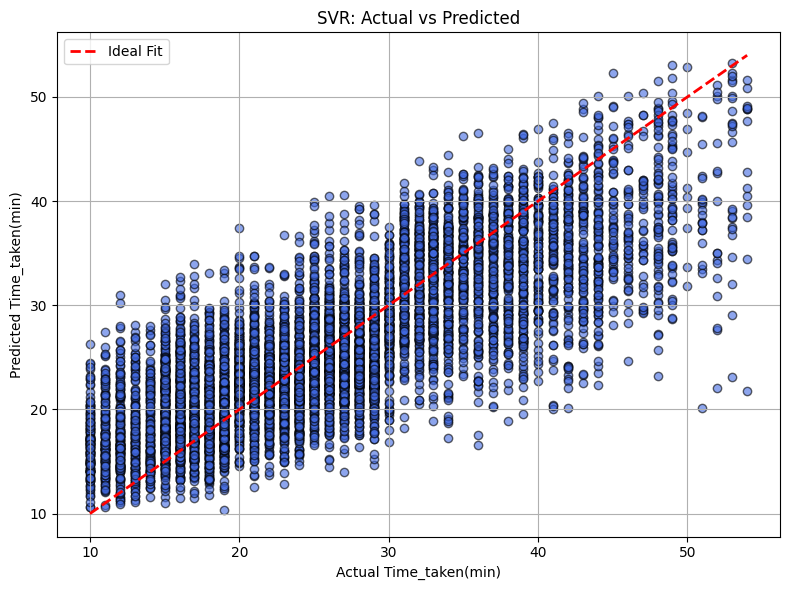

In [15]:
import matplotlib.pyplot as plt
y_pred = best_model.predict(X_test)

# Scatter plot: Actual vs Predicted
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.6, color='royalblue', edgecolor='k')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Ideal Fit')
plt.xlabel('Actual Time_taken(min)')
plt.ylabel('Predicted Time_taken(min)')
plt.title('SVR: Actual vs Predicted')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()